# Labwork 5

(540, 720, 3)


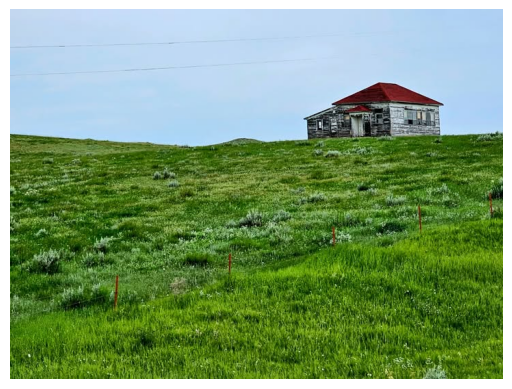

In [1]:
from matplotlib import pyplot as plt
from matplotlib import image
from time import time

from PIL import Image
import numpy as np
from numba import cuda

if not hasattr(np, 'row_stack'):
        np.row_stack = np.vstack

# img = image.imread("cat.jpg")
img = np.array(Image.open("../data/house.jpg").convert("RGB"))

print (img.shape)
pixelCount = img.shape[0] * img.shape[1]
plt.imshow(img)
plt.axis("off")
plt.show()



In [2]:
def save_log(data):
    with open("log.csv", "a") as f:
        f.write(f"{data}\n")

In [3]:
# Precomputed 7x7 kernel for Gaussian blur
kernel = np.array([[0, 0, 1, 2, 1, 0, 0],
                   [0, 3, 13, 22, 13, 3, 0],
                   [1, 13, 59, 97, 59, 13, 1],
                   [2, 22, 97, 159, 97, 22, 2],
                   [1, 13, 59, 97, 59, 13, 1],
                   [0, 3, 13, 22, 13, 3, 0],
                   [0, 0, 1, 2, 1, 0, 0]], dtype=np.float32)


CPU time: 120.981555 seconds


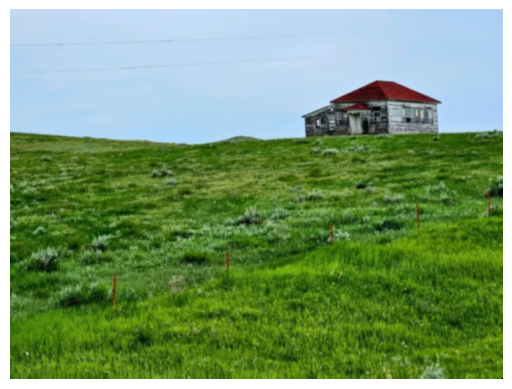

In [4]:
# CPU version
def blur_cpu(src, dst):
    for i in range(src.shape[0]):
        for j in range(src.shape[1]):
            total = 0
            for ki in range(kernel.shape[0]):
                for kj in range(kernel.shape[1]):
                    if (i + ki >= 0 and i + ki < src.shape[0] and j + kj >= 0 and j + kj < src.shape[1]):
                        dst[i, j, 0] += kernel[ki, kj] * src[i + ki, j + kj, 0]
                        dst[i, j, 1] += kernel[ki, kj] * src[i + ki, j + kj, 1]
                        dst[i, j, 2] += kernel[ki, kj] * src[i + ki, j + kj, 2]
                        total += kernel[ki, kj]
            if total > 0 :
                dst[i, j, 0] = dst[i, j, 0] / total
                dst[i, j, 1] = dst[i, j, 1] / total
                dst[i, j, 2] = dst[i, j, 2] / total

output = np.zeros_like(img, dtype=np.float32) 
t0=time()
blur_cpu(img, output)
duration = time() - t0
print(f"CPU time: {duration:.6f} seconds")
plt.imshow(output.astype(np.uint8))
plt.axis("off")
plt.show()

In [9]:
# No shared memory GPU version
@cuda.jit
def blur_gpu_no_shared(src, dst, kernel):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y 
    
    if tidx >=  src.shape[0] and tidy >= src.shape[1]:
        return

    red, green, blue, weight_sum = 0, 0, 0, 0
    
    for ki in range(kernel.shape[0]):
        for kj in range(kernel.shape[1]):
            if (tidx + ki >= 0 and tidx + ki < src.shape[0] and tidy + kj >= 0 and tidy + kj < src.shape[1]):
                red += kernel[ki, kj] * src[tidx + ki, tidy + kj, 0]
                green += kernel[ki, kj] * src[tidx + ki, tidy + kj, 1]
                blue += kernel[ki, kj] * src[tidx + ki, tidy + kj, 2]
                weight_sum += kernel[ki,kj]
                
    if weight_sum > 0:
        dst[tidx, tidy, 0] = red / weight_sum
        dst[tidx, tidy, 1] = green / weight_sum
        dst[tidx, tidy, 2] = blue / weight_sum
        

GPU time: 10.403872 milliseconds


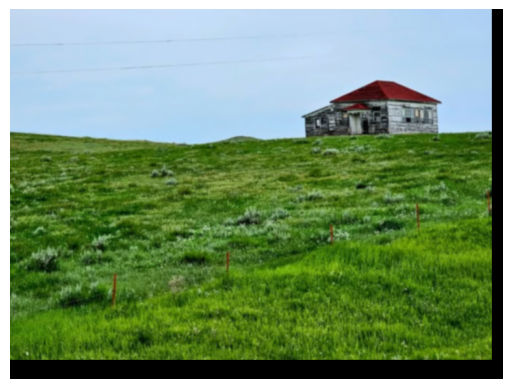

In [10]:
devInput = cuda.to_device(img)
devKernel = cuda.to_device(kernel)
devOutput = cuda.device_array(img.shape, dtype=np.uint8)
blockSize = (32, 32)
gridSize = (img.shape[0]//blockSize[0], img.shape[1]//blockSize[1])


blur_gpu_no_shared[gridSize, blockSize](devInput, devOutput, devKernel)

t0=time()
blur_gpu_no_shared[gridSize, blockSize](devInput, devOutput, devKernel)
cuda.synchronize()

duration = time() - t0
print(f"GPU time: {duration*1000:.6f} milliseconds")
hostOutput = devOutput.copy_to_host()

plt.imshow(hostOutput.astype(np.uint8))
plt.axis("off")
plt.show()

In [11]:
# Shared memory GPU version
from numba import cuda
from numba import uint8

@cuda.jit
def blur_gpu_shared(src, dst, kernel):
    tsx, tsy = 16 + 6, 16 + 6
    
    bdimx, bdimy = cuda.blockDim.x, cuda.blockDim.y
    bidx, bidy = cuda.blockIdx.x, cuda.blockIdx.y
    
    tile = cuda.shared.array((tsx, tsy, 3), dtype=uint8)
    tx, ty = cuda.threadIdx.x, cuda.threadIdx.y
    tidx, tidy = tx + bidx * bdimx, ty + bidy * bdimy

    for i in range(tx, tsx, bdimx):
        for j in range(ty, tsy, bdimy):
            x = bidx * bdimx + i - 3
            y = bidy * bdimy + j - 3
            if 0 <= x < src.shape[0] and 0 <= y < src.shape[1]:
                tile[i, j, 0] = src[x, y, 0]
                tile[i, j, 1] = src[x, y, 1]
                tile[i, j, 2] = src[x, y, 2]
            else:
                tile[i, j, 0] = 0
                tile[i, j, 1] = 0
                tile[i, j, 2] = 0
    cuda.syncthreads()

    if tidx >= src.shape[0] or tidy >= src.shape[1]:
        return

    red, green, blue, weight_sum = 0, 0, 0, 0

    for ki in range(kernel.shape[0]):
        for kj in range(kernel.shape[1]):
            if 0 <= tidx + ki - 3 < src.shape[0] and 0 <= tidy + kj - 3 < src.shape[1]:
                weight = kernel[ki, kj]
                red += weight * tile[tx + ki, ty + kj, 0]
                green += weight * tile[tx + ki, ty + kj, 1]
                blue += weight * tile[tx + ki, ty + kj, 2]
                weight_sum += weight

    if weight_sum > 0:
        dst[tidx, tidy, 0] = red / weight_sum
        dst[tidx, tidy, 1] = green / weight_sum
        dst[tidx, tidy, 2] = blue / weight_sum

GPU time: 6.506920 milliseconds


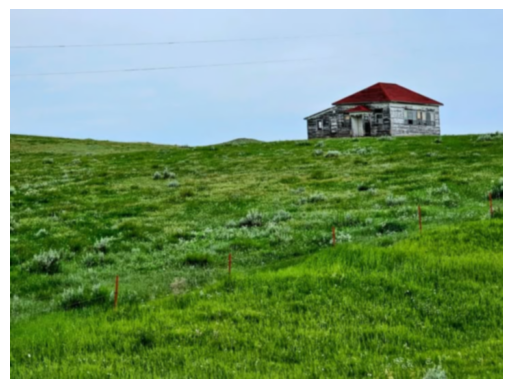

In [12]:
blockSize = (16, 16)
gridSize = ((img.shape[0] + blockSize[0] - 1) // blockSize[0],
            (img.shape[1] + blockSize[1] - 1) // blockSize[1])
img = np.ascontiguousarray(img)
devInput = cuda.to_device(img)
devKernel = cuda.to_device(kernel)
devOutput = cuda.device_array(img.shape, dtype=np.float32)

blur_gpu_shared[gridSize, blockSize](devInput, cuda.device_array(img.shape, dtype=np.float32), devKernel)

t0=time()
blur_gpu_shared[gridSize, blockSize](devInput, devOutput, devKernel) 
cuda.synchronize()

duration = time() - t0
print(f"GPU time: {duration*1000:.6f} milliseconds")
hostOutput = devOutput.copy_to_host()
output_shared = devOutput.copy_to_host()

plt.imshow(output_shared.astype(np.uint8))
plt.axis("off")
plt.show()